In [1]:
import seisbench
import numpy as np
import torch
import obspy
import matplotlib.pyplot as plt
import pandas as pd
from obspy import UTCDateTime
import os


In [2]:
import seisbench.models as sbm

sbm.PhaseNet.list_pretrained()                  
model = sbm.PhaseNet.from_pretrained("instance")

/opt/anaconda3/envs/ege-seisbench/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_

In [3]:
stream = obspy.read('/home/ege/10NOV_18-19/BALB_10NOV_18-19.mseed')
catalog=pd.read_csv('/home/ege/recovar/reproducibility/phasenet_eqt/10NOV_18-19.csv')
catalog['arrival_time'] = pd.to_datetime(catalog['arrival_time'])

annotations = model.annotate(stream)

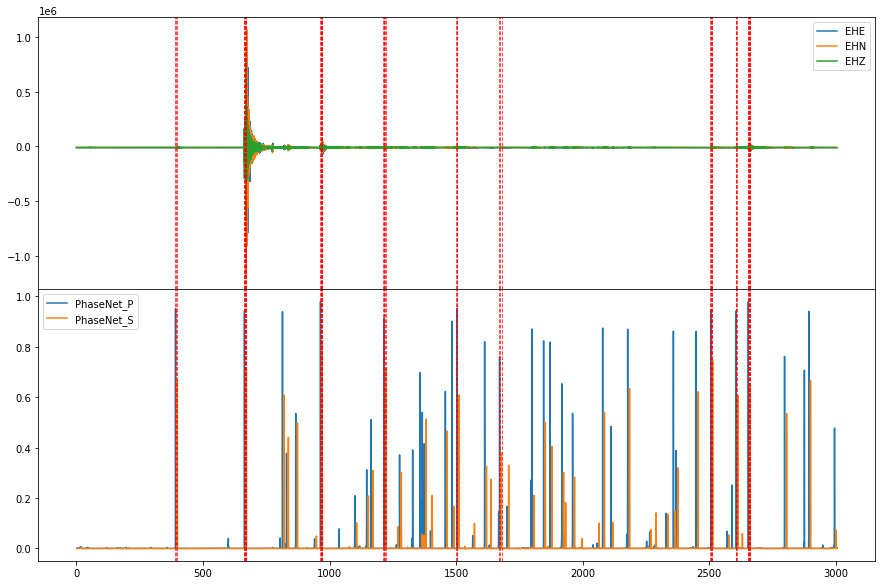

In [4]:
fig = plt.figure(figsize=(15, 10))
axs = fig.subplots(2, 1, sharex=True, gridspec_kw={"hspace": 0})
offset = annotations[0].stats.starttime - stream[0].stats.starttime

for i in range(3):
    axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
    if annotations[i].stats.channel[-1] != "N":
        axs[1].plot(
            annotations[i].times() + offset,
            annotations[i].data,
            label=annotations[i].stats.channel,
        )

for _, row in catalog.iterrows():
    pick_time = UTCDateTime(row['arrival_time'])
    pick_offset = pick_time - stream[0].stats.starttime
    for ax in axs:
        ax.axvline(pick_offset, color='red', linestyle='--', alpha=0.7, linewidth=1)

axs[0].legend()
axs[1].legend()

In [5]:
annotations

6 Trace(s) in Stream:
KO.BALB..PhaseNet_P | 2025-11-10T18:09:59.880000Z - 2025-11-10T19:00:01.320000Z | 100.0 Hz, 300145 samples
KO.BALB..PhaseNet_S | 2025-11-10T18:09:59.880000Z - 2025-11-10T19:00:01.320000Z | 100.0 Hz, 300145 samples
KO.BALB..PhaseNet_N | 2025-11-10T18:09:59.880000Z - 2025-11-10T19:00:01.320000Z | 100.0 Hz, 300145 samples
KO.BALB..PhaseNet_P | 2025-11-10T18:09:55.800000Z - 2025-11-10T19:00:03.140000Z | 100.0 Hz, 300735 samples
KO.BALB..PhaseNet_S | 2025-11-10T18:09:55.800000Z - 2025-11-10T19:00:03.140000Z | 100.0 Hz, 300735 samples
KO.BALB..PhaseNet_N | 2025-11-10T18:09:55.800000Z - 2025-11-10T19:00:03.140000Z | 100.0 Hz, 300735 samples

In [6]:
import seisbench.models as sbm
from scipy.signal import find_peaks
import obspy
def extract_windows_phasenet(stream, model_name='instance', threshold=0.5, phase='P', window_samples=4000):
    model = sbm.PhaseNet.from_pretrained(model_name)
    
    stream_sync = stream.copy()
    stream_sync.trim(
        starttime=max([tr.stats.starttime for tr in stream_sync]),
        endtime=min([tr.stats.endtime for tr in stream_sync]),
        pad=True,
        fill_value=0
    )
    
    annotations = model.annotate(stream_sync)
    phase_channel = [tr for tr in annotations if tr.stats.channel.endswith(phase)][0]
    peaks, _ = find_peaks(phase_channel.data, height=threshold, distance=100)
    
    windows = []
    pick_times = []
    half_samples = window_samples // 2
    
    for peak_idx in peaks:
        start_sample = peak_idx - half_samples
        end_sample = start_sample + window_samples
        
        if start_sample >= 0 and end_sample <= len(stream_sync[0].data):
            windowed_stream = obspy.Stream()
            for tr in stream_sync:
                windowed = tr.copy()
                windowed.data = tr.data[start_sample:end_sample]
                windowed.stats.starttime = tr.stats.starttime + start_sample / tr.stats.sampling_rate
                windowed_stream.append(windowed)
            
            windows.append(windowed_stream)
            pick_time = phase_channel.stats.starttime + peak_idx / phase_channel.stats.sampling_rate
            pick_times.append(pick_time)
    
    return windows, pick_times

In [7]:
windows, pick_times = extract_windows_phasenet(stream)

/opt/anaconda3/envs/ege-seisbench/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.load(f"{path_

In [8]:
windows

[6 Trace(s) in Stream:
KO.BALB..EHE | 2025-11-10T18:16:06.210000Z - 2025-11-10T18:16:46.200000Z | 100.0 Hz, 4000 samples
KO.BALB..EHN | 2025-11-10T18:16:06.210000Z - 2025-11-10T18:16:46.200000Z | 100.0 Hz, 4000 samples
KO.BALB..EHZ | 2025-11-10T18:16:06.210000Z - 2025-11-10T18:16:46.200000Z | 100.0 Hz, 4000 samples
KO.BALB..HNE | 2025-11-10T18:16:06.210000Z - 2025-11-10T18:16:46.200000Z | 100.0 Hz, 4000 samples
KO.BALB..HNN | 2025-11-10T18:16:06.210000Z - 2025-11-10T18:16:46.200000Z | 100.0 Hz, 4000 samples
KO.BALB..HNZ | 2025-11-10T18:16:06.210000Z - 2025-11-10T18:16:46.200000Z | 100.0 Hz, 4000 samples,
 6 Trace(s) in Stream:
KO.BALB..EHE | 2025-11-10T18:20:38.500000Z - 2025-11-10T18:21:18.490000Z | 100.0 Hz, 4000 samples
KO.BALB..EHN | 2025-11-10T18:20:38.500000Z - 2025-11-10T18:21:18.490000Z | 100.0 Hz, 4000 samples
KO.BALB..EHZ | 2025-11-10T18:20:38.500000Z - 2025-11-10T18:21:18.490000Z | 100.0 Hz, 4000 samples
KO.BALB..HNE | 2025-11-10T18:20:38.500000Z - 2025-11-10T18:21:18.490000

In [9]:
import os
import pandas as pd
def save_windows(windows, pick_times, output_dir='phasenet_windows'):
    os.makedirs(output_dir, exist_ok=True)
    
    metadata = []
    for i, (window, pick_time) in enumerate(zip(windows, pick_times)):
        # Save waveform
        filename = f'window_{i:04d}.mseed'
        window.write(os.path.join(output_dir, filename), format='MSEED')
        
        # Collect metadata
        metadata.append({
            'index': i,
            'filename': filename,
            'pick_time': pick_time.isoformat(),
            'station': window[0].stats.station,
            'network': window[0].stats.network,
            'start_time': window[0].stats.starttime.isoformat(),
            'end_time': window[0].stats.endtime.isoformat()
        })
    
    df = pd.DataFrame(metadata)
    df.to_csv(os.path.join(output_dir, 'phasenet_picks_10NOV-18-19_metadata.csv'), index=False)

In [10]:
save_windows(windows,pick_times)